# Week 2 — Exploratory Data Analysis and Visualization
**Dataset:** UCI Wine Recognition dataset (via scikit-learn)

This notebook explores 13 chemical measurements across three wine cultivars: summary statistics, distributions, outliers, correlations, and class-level comparisons. Full write-up (including the preprocessing-impact discussion) is in `Week_2_Report.docx`.

## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.frame.copy()
df["target_name"] = df["target"].map(dict(enumerate(wine.target_names)))

print(df.shape)
df.head()

(178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Initial Inspection

In [2]:
print(df.info())
print(df.isna().sum())
print(df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

## 3. Class Distribution

target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64
target_name
class_1    39.89
class_0    33.15
class_2    26.97
Name: count, dtype: float64


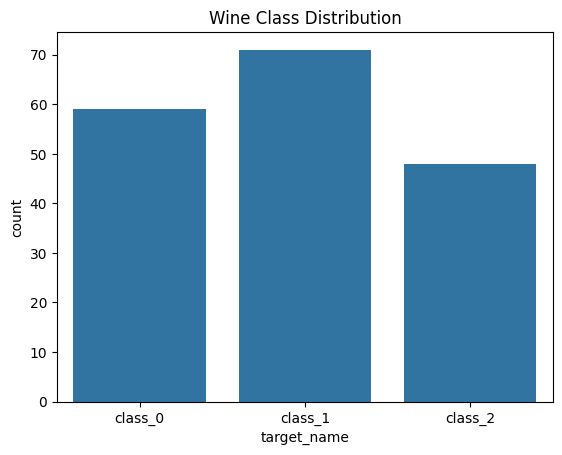

In [3]:
class_counts = df["target_name"].value_counts()
print(class_counts)
print((class_counts / len(df) * 100).round(2))

sns.countplot(data=df, x="target_name")
plt.title("Wine Class Distribution")
plt.show()

## 4. Summary Statistics

In [4]:
features = [c for c in df.columns if c not in ("target", "target_name")]
summary = df[features].describe().T
summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 5. Univariate Distributions

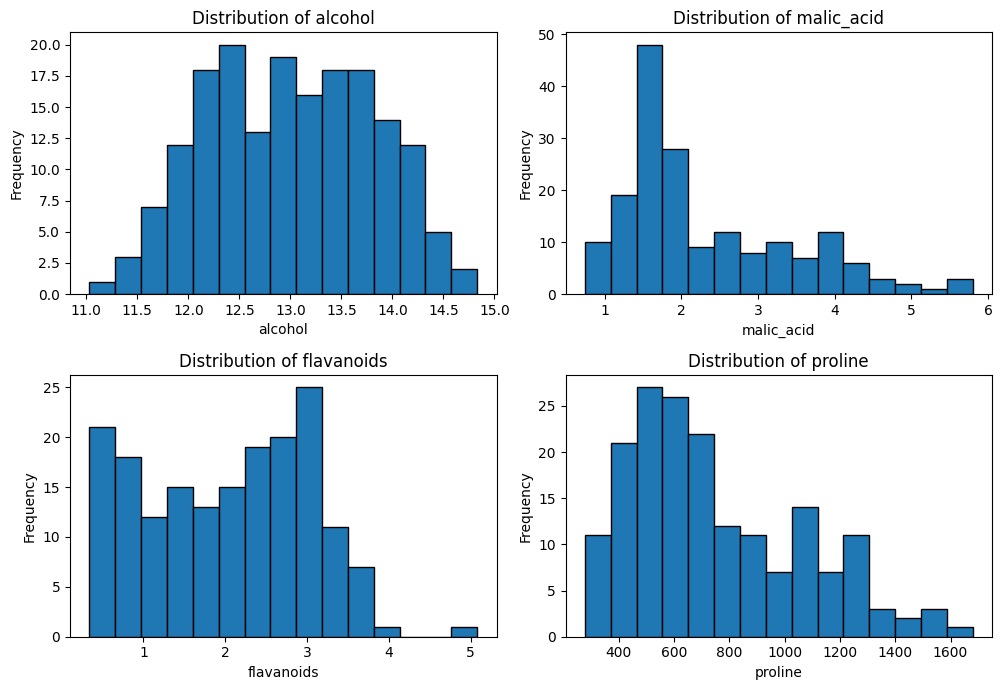

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, column in zip(axes.ravel(), ["alcohol", "malic_acid", "flavanoids", "proline"]):
    ax.hist(df[column], bins=15, edgecolor="black")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Outlier Screening (IQR Rule)

In [6]:
outlier_counts = {}
for column in features:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_counts[column] = ((df[column] < lower) | (df[column] > upper)).sum()

pd.Series(outlier_counts).sort_values(ascending=False)

magnesium                       4
alcalinity_of_ash               4
color_intensity                 4
malic_acid                      3
ash                             3
proanthocyanins                 2
hue                             1
alcohol                         0
total_phenols                   0
nonflavanoid_phenols            0
flavanoids                      0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

## 7. Boxplots by Class

/tmp/ipykernel_335/553167855.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(df.target_name.unique()))


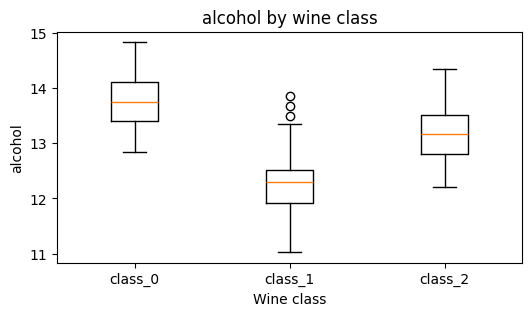

/tmp/ipykernel_335/553167855.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(df.target_name.unique()))


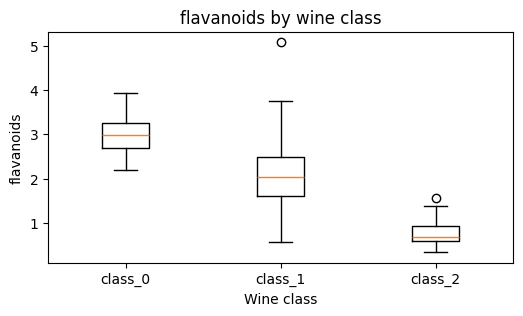

/tmp/ipykernel_335/553167855.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(df.target_name.unique()))


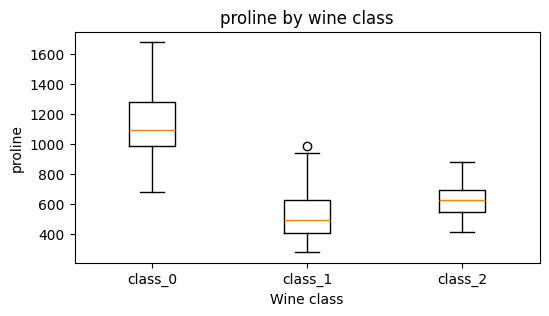

/tmp/ipykernel_335/553167855.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(df.target_name.unique()))


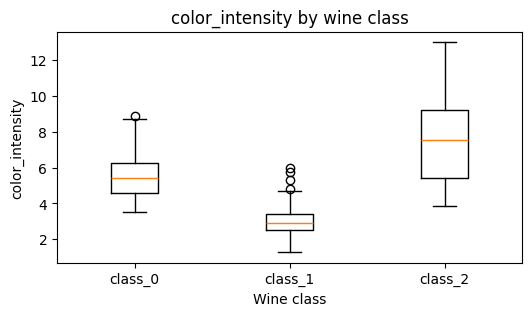

In [7]:
selected = ["alcohol", "flavanoids", "proline", "color_intensity"]
for column in selected:
    groups = [df.loc[df.target_name == cls, column] for cls in sorted(df.target_name.unique())]
    plt.figure(figsize=(6, 3))
    plt.boxplot(groups, labels=sorted(df.target_name.unique()))
    plt.title(f"{column} by wine class")
    plt.xlabel("Wine class")
    plt.ylabel(column)
    plt.show()

## 8. Bivariate Relationship: Alcohol vs Proline

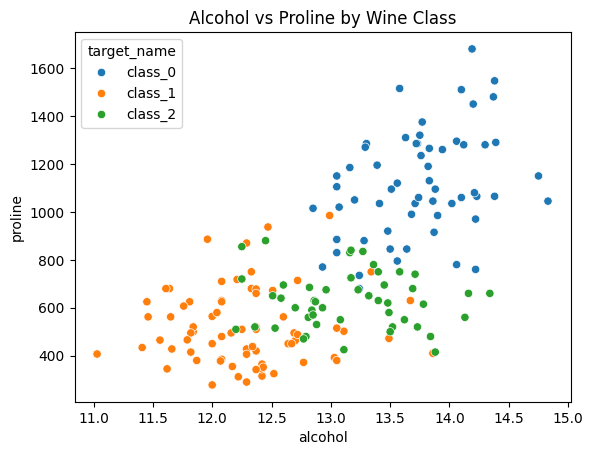

In [8]:
sns.scatterplot(data=df, x="alcohol", y="proline", hue="target_name")
plt.title("Alcohol vs Proline by Wine Class")
plt.show()

## 9. Correlation Matrix

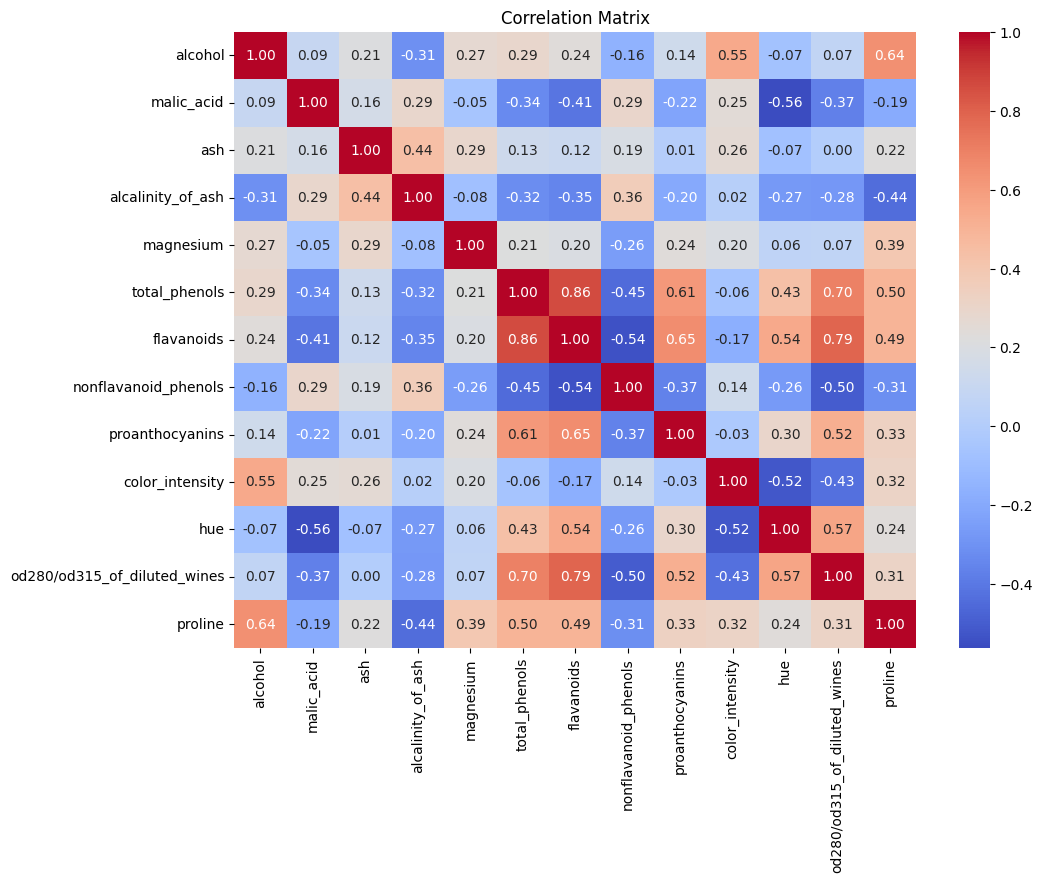

Total Phenols vs Flavanoids correlation: 0.865


In [9]:
corr = df[features].corr(method="pearson")
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

print("Total Phenols vs Flavanoids correlation:", round(corr.loc["total_phenols", "flavanoids"], 3))

## 10. Class-Level Feature Means

             alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
target_name                                                            
class_0        13.74        2.01  2.46              17.04     106.34   
class_1        12.28        1.93  2.24              20.24      94.55   
class_2        13.15        3.33  2.44              21.42      99.31   

             total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
target_name                                                                     
class_0               2.84        2.98                  0.29             1.90   
class_1               2.26        2.08                  0.36             1.63   
class_2               1.68        0.78                  0.45             1.15   

             color_intensity   hue  od280/od315_of_diluted_wines  proline  
target_name                                                                
class_0                 5.53  1.06                          3.16  1115.71  
class

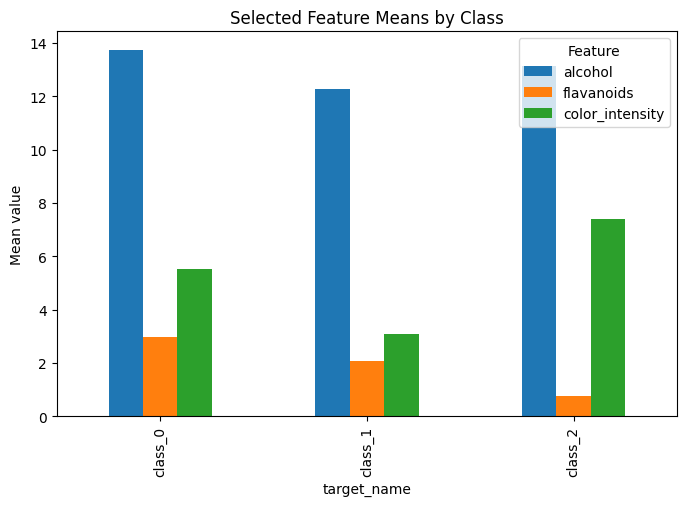

In [10]:
class_means = df.groupby("target_name")[features].mean().round(2)
print(class_means)

class_means[["alcohol", "flavanoids", "color_intensity"]].plot(kind="bar", figsize=(8, 5))
plt.ylabel("Mean value")
plt.title("Selected Feature Means by Class")
plt.legend(title="Feature")
plt.show()

## Conclusion
Alcohol, Flavanoids and Proline show the clearest class separation, Total Phenols and Flavanoids are strongly correlated (r ≈ 0.865), and the class split (71/59/48) is mildly imbalanced. See `Week_2_Report.docx`, Section 14.1, for exactly how these findings should shape preprocessing choices in later modelling (scaling, multicollinearity, stratified splits).